In [38]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns


In [41]:
df = pd.read_csv("movies.csv",lineterminator="\n")
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [42]:
df["Release_Date"]=pd.to_datetime(df["Release_Date"])
print(df["Release_Date"].dtype)

datetime64[ns]


In [43]:
df["Release_Date"]= df["Release_Date"].dt.year

In [46]:
df = df.drop(["Poster_Url","Vote_Count"],axis=1)

In [47]:
stats = df['Vote_Average'].describe()

q1 = stats['25%']
q2 = stats['50%']
q3 = stats['75%']

# Categorization based on describe()
def categorize_vote(vote):
    if vote >= q3:
        return 'Popular'
    elif vote >= q2:
        return 'Average'
    elif vote >= q1:
        return 'Below Average'
    else:
        return 'Not Popular'

# Apply category
df['Category'] = df['Vote_Average'].apply(categorize_vote)

In [48]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Average,Original_Language,Genre,Category
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8.3,en,"Action, Adventure, Science Fiction",Popular
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,8.1,en,"Crime, Mystery, Thriller",Popular
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,6.3,en,Thriller,Below Average
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,7.7,en,"Animation, Comedy, Family, Fantasy",Popular
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,7.0,en,"Action, Adventure, Thriller, War",Average


In [49]:
df = df.drop(["Vote_Average"],axis=1)

In [50]:
category_counts = df['Category'].value_counts()
print(category_counts)

Category
Popular          2840
Average          2449
Below Average    2331
Not Popular      2207
Name: count, dtype: int64


In [52]:
df.isna().sum()

,0
Release_Date,0
Title,0
Overview,0
Popularity,0
Original_Language,0
Genre,0
Category,0


/tmp/ipython-input-1284018328.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


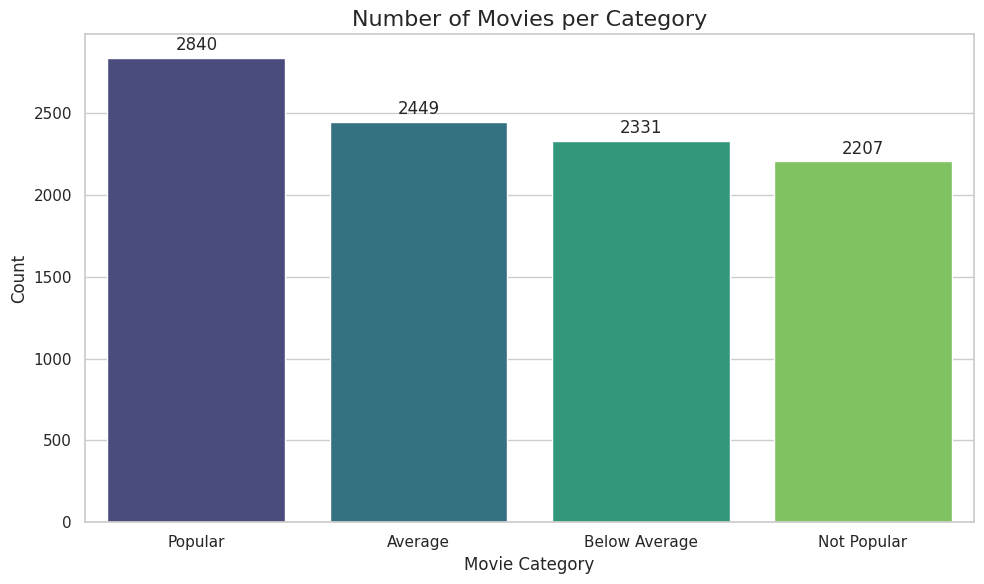

In [53]:
# 1. Set the visual style and figure size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Define the logical order of categories for the x-axis
category_order = ['Popular', 'Average', 'Below Average', 'Not Popular']

# 3. Create the count plot
# We use the 'Category' column we created earlier
ax = sns.countplot(
    data=df,
    x='Category',
    order=category_order,
    palette='viridis'
)

# 4. Add labels and a title
plt.title('Number of Movies per Category', fontsize=16)
plt.xlabel('Movie Category', fontsize=12)
plt.ylabel('Count', fontsize=12)

# 5. Optional: Add the exact count on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

# 6. Display the plot
plt.tight_layout()
plt.show()

/tmp/ipython-input-3828688650.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


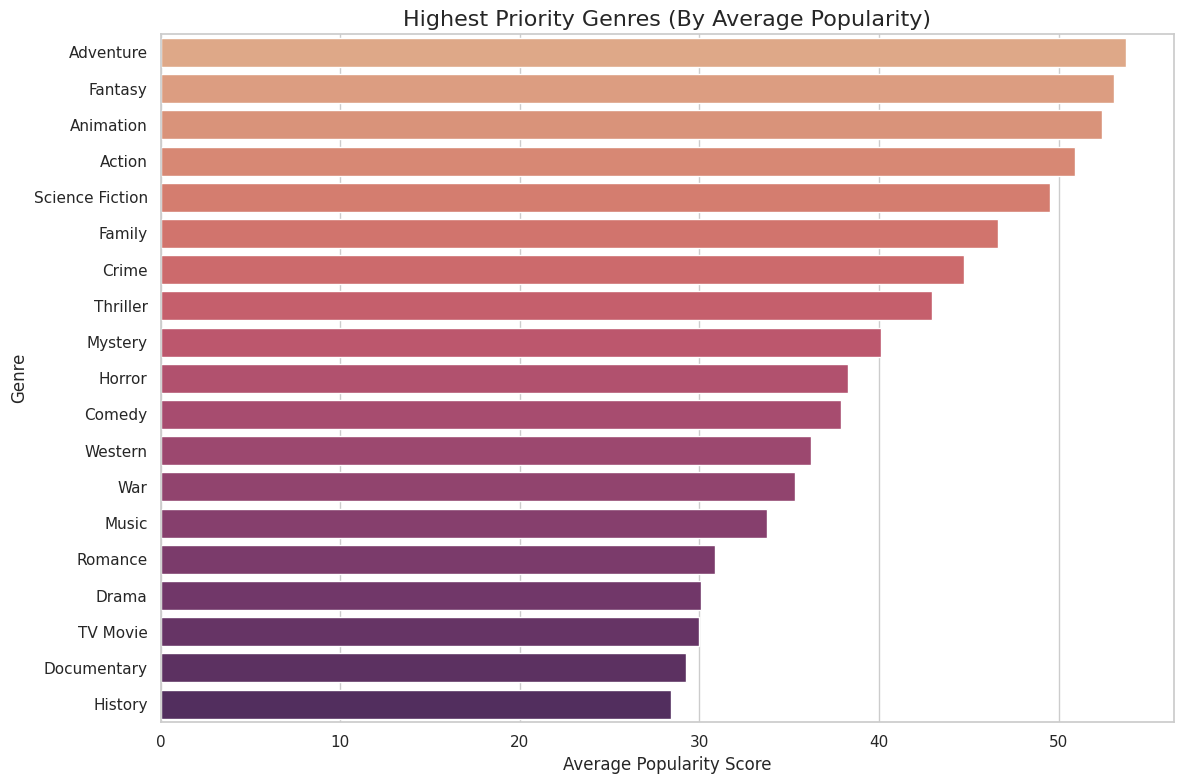

In [56]:
df_genre = df.copy()
df_genre['Genre'] = df_genre['Genre'].str.split(', ')
df_genre = df_genre.explode('Genre')

plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_genre,
    x='Popularity',
    y='Genre',
    estimator=np.mean,
    errorbar=None,
    palette='flare',
    order=df_genre.groupby('Genre')['Popularity'].mean().sort_values(ascending=False).index
)

plt.title('Highest Priority Genres (By Average Popularity)', fontsize=16)
plt.xlabel('Average Popularity Score', fontsize=12)
plt.ylabel('Genre', fontsize=12)

plt.tight_layout()
plt.show()


/tmp/ipython-input-2601010090.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


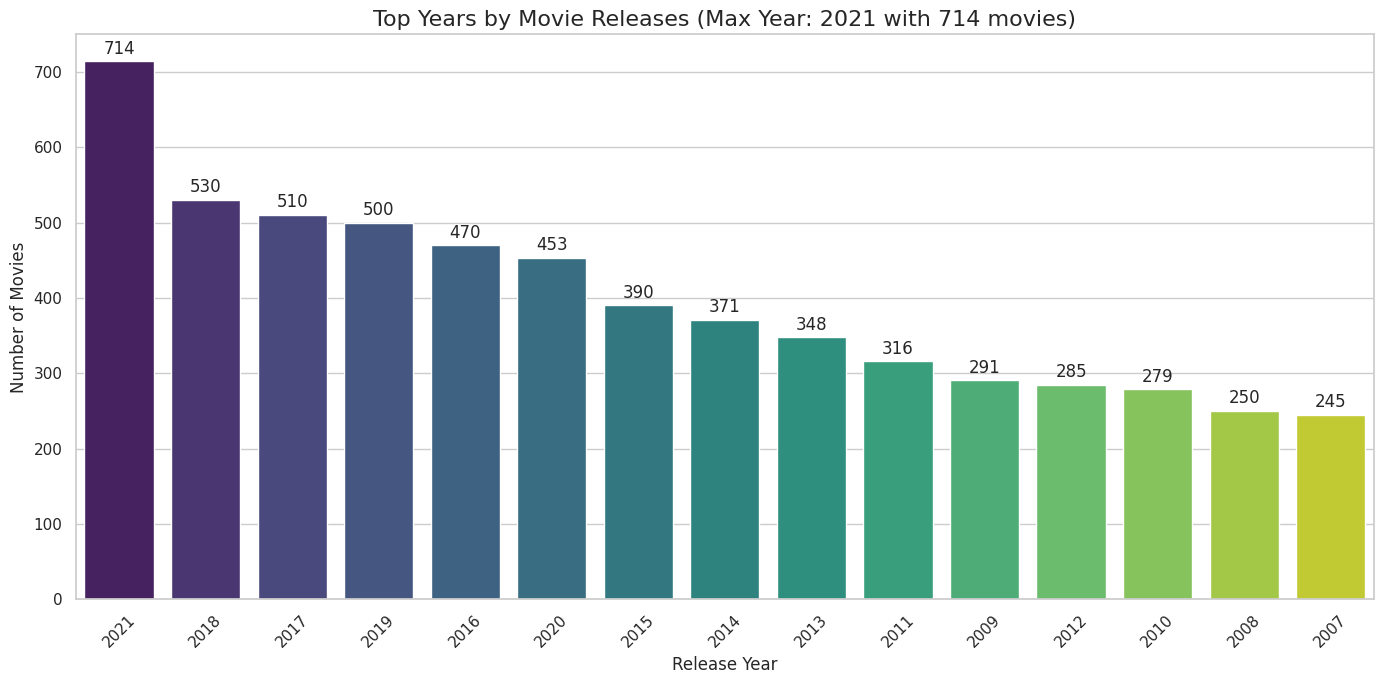

In [57]:
# 1. Set the visual style and figure size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 2. Identify the year with the maximum releases for the title
max_year = df['Release_Date'].value_counts().idxmax()
max_count = df['Release_Date'].value_counts().max()

# 3. Create the count plot
# We order by value_counts().index to show the years with the most movies first
ax = sns.countplot(
    data=df,
    x='Release_Date',
    palette='viridis',
    order=df['Release_Date'].value_counts().iloc[:15].index  # Showing top 15 years
)

# 4. Add titles and labels
plt.title(f'Top Years by Movie Releases (Max Year: {max_year} with {max_count} movies)', fontsize=16)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.xticks(rotation=45)

# 5. Add count labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()


In [60]:
df['combined_features'] = df['Overview'] + " " + df['Genre']


In [61]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['combined_features'])


In [62]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)


In [63]:
TITLE_COL = 'Title'


In [64]:
df['title_clean'] = df[TITLE_COL].astype(str).str.lower().str.strip()


In [65]:
def recommend_movies(movie_name, num_recommendations=5):
    movie_name = movie_name.lower().strip()

    # Partial & case-insensitive match
    matches = df[df['title_clean'].str.contains(movie_name, na=False)]

    if matches.empty:
        return "Movie not found. Try another title."

    # Pick best match
    idx = matches.index[0]

    # Similarity scores
    similarity_scores = list(enumerate(cosine_sim[idx]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    # Top N recommendations
    top_movies = similarity_scores[1:num_recommendations+1]

    return df.iloc[[i[0] for i in top_movies]][TITLE_COL].tolist()


In [69]:
recommend_movies("avengers", 5)


['Avengers: Endgame',
 'Avengers Grimm: Time Wars',
 'Next Avengers: Heroes of Tomorrow',
 'Phineas and Ferb: Mission Marvel',
 'Scooby-Doo and the Alien Invaders']

In [70]:
def precision_at_k(movie_name, k=5):
    movie_name = movie_name.lower().strip()

    matches = df[df['title_clean'].str.contains(movie_name, na=False)]
    if matches.empty:
        return None

    idx = matches.index[0]

    # Original movie genres
    original_genres = set(df.loc[idx, 'Genre'].split(', '))

    # Similarity scores
    similarity_scores = list(enumerate(cosine_sim[idx]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    # Top K recommendations
    top_k = similarity_scores[1:k+1]

    relevant_count = 0
    for i, _ in top_k:
        recommended_genres = set(df.loc[i, 'Genre'].split(', '))
        if original_genres.intersection(recommended_genres):
            relevant_count += 1

    precision = relevant_count / k
    return precision


In [71]:
precision = precision_at_k("avengers", k=5)
print("Precision@5:", precision)


Precision@5: 1.0
